Adjusted the outstanding amount as 0 if the amount<9.99 changing the claim status as adjusted

In [1]:
import pandas as pd


df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Aetna_only.csv",
   encoding="utf-8"       
)

print("File loaded successfully")

# Convert Outstanding Amt to numeric (removes $, commas, text)
df["Outstanding Amt"] = pd.to_numeric(df["Outstanding Amt"], errors="coerce")

# Apply rule: If Outstanding Amt < 9.99
mask = df["Outstanding Amt"] < 9.99

# Set Outstanding Amt to 0
df.loc[mask, "Outstanding Amt"] = 0

# Update Claim Status
df.loc[mask, "Claim Status"] = "Adjusted"

# Save updated file
df.to_csv(
    "/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Atena_copy_adjusted.csv",index=False
)

print("Update complete! Adjusted rows:", mask.sum())

File loaded successfully
Update complete! Adjusted rows: 229


In [2]:
#merging two files:
import pandas as pd

df1 = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Atena_copy_adjusted.csv")
df2 = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Final copy_data.csv")

merged = pd.concat([df1, df2], ignore_index=True)

merged.to_csv("Final data_copy.csv", index=False)

print("Files merged successfully")


Files merged successfully


In [3]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

#reading the file
claim_data = pd.read_csv('/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/eda_data_2026.csv')
claim_data


,Claim ID,Provider ID,Payor ID,Insurance Name,Insurance Type,Treatment Category,Patient ID,Date of Service,Billed Amt,Outstanding Amt,Allowed Amount,Patients Resp,Invoice#,Invoice Creation Date,Diagnosis Code,Current Status,Reason Code,Follow-up Required,AR Status,Claim Status
0,CLM-VA-944904,PRV-VA-18938,87726,UNITED HEALTHCARE,PPO,Specialist Consultation,1008435610V090547,2025-06-13,319.00,319.00,234.00,85.00,P1261566691,2025-07-17,E11.9,Investigation Sent,CO-119,No,In Progress,Pending
1,CLM-TRIC-625095,PRV-TRIC-44007,99726,TRICARE,HMO,Specialist Consultation,85523700,2025-04-04,267.00,267.00,241.26,25.74,P1250188961,2025-04-05,E11.9,Check in process,CO-16,No,In Progress,Pending
2,CLM-TRIC-684179,PRV-TRIC-42495,99726,TRICARE,HMO,Laboratory Services,8609450,2025-05-31,39.00,39.00,25.66,13.34,P1256728390,2025-06-02,R51.9,Check in process,CO-119,No,In Progress,Pending
3,CLM-TRIC-897213,PRV-TRIC-38461,99726,TRICARE,POS,Physical Therapy,518792500,2024-09-06,123.00,123.00,95.89,27.11,P1226005231,2024-09-07,M25.50,> 365+ days,CO-197,No,In Progress,Pending
4,CLM-VA-578292,PRV-VA-50011,87726,UNITED HEALTHCARE,HMO,Physical Therapy,204268984,2025-04-23,376.00,376.00,232.28,143.72,P1252816245,2025-07-15,M25.50,Claim set to pay,CO-119,No,In Progress,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,CLM-CO-651797,PRV-BCBS-57122,60054,AETNA,AETNA HMO,Specialist Consultation,PT-CO-225568,2024-11-11,185.06,185.06,126.83,58.23,P1269090021,2025-09-11,E78.5,Claim in process,CO-119,No,In Progress,Pending
9989,CLM-CO-314246,PRV-CO-78954,60054,AETNA,AETNA HMO,Primary Care Visit,PT-CO-342806,2024-11-09,158.60,158.60,120.84,37.76,P1269090022,2025-06-11,E78.5,Claim in process,CO-119,No,In Progress,Pending
9990,CLM-CO-170301,PRV-CO-82722,60054,AETNA,AETNA HMO,Laboratory Services,PT-CO-856868,2024-10-31,164.23,164.23,120.94,43.29,P1269090010,2025-08-17,E78.5,Claim in process,CO-119,No,In Progress,Pending
9991,CLM-CO-994679,PRV-CO-10250,60054,AETNA,AETNA HMO,Diagnostic Imaging,PT-CO-856868,2025-02-11,186.09,186.09,134.19,51.90,P1269090010,2025-05-11,E78.5,Claim in process,CO-119,No,In Progress,Pending


Data Cleaning

standardizing column names:

In [4]:
#standardizing the column names by filling underscore_ to make it readable in python.
claim_data.columns = (
    claim_data.columns
    .str.strip().str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)
claim_data.columns

Index(['claim_id', 'provider_id', 'payor_id', 'insurance_name',
       'insurance_type', 'treatment_category', 'patient_id', 'date_of_service',
       'billed_amt', 'outstanding_amt', 'allowed_amount', 'patients_resp',
       'invoice#', 'invoice_creation_date', 'diagnosis_code', 'current_status',
       'reason_code', 'follow_up_required', 'ar_status', 'claim_status'],
      dtype='object')

checking missing values

In [5]:
claim_data.isnull().sum()

claim_id                 0
provider_id              0
payor_id                 0
insurance_name           0
insurance_type           0
treatment_category       0
patient_id               0
date_of_service          0
billed_amt               0
outstanding_amt          0
allowed_amount           0
patients_resp            0
invoice#                 0
invoice_creation_date    0
diagnosis_code           0
current_status           0
reason_code              0
follow_up_required       0
ar_status                0
claim_status             0
dtype: int64

checking outliers

In [6]:
numeric_cols = claim_data.select_dtypes(include=["number"]).columns

# Looping through each numeric column
for col in numeric_cols:
    # Calculate the first quartile (25th percentile)
    Q1 = claim_data[col].quantile(0.25)
    # Calculate the third quartile (75th percentile)
    Q3 = claim_data[col].quantile(0.75)
    # Computing the Interquartile Range (IQR)
    IQR = Q3 - Q1
    #Defining the lower boundary for outliers
    lower_bound = Q1 - 1.5 * IQR
    #Defining the upper boundary for outliers
    upper_bound = Q3 + 1.5 * IQR
    #Filtering rows where values fall outside the acceptable range
    outliers = claim_data[(claim_data[col] < lower_bound) | (claim_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

billed_amt: 883 outliers
outstanding_amt: 707 outliers
allowed_amount: 871 outliers
patients_resp: 1678 outliers


checking the duplicates

In [7]:
duplicate_count = claim_data.duplicated().sum()
duplicate_count

0

converting the columns(date_of_Service,invoice_creation_date,billed_amt,outstanding_Amt) into correct datatype

In [8]:
claim_data["date_of_service"] = pd.to_datetime(claim_data["date_of_service"], errors="coerce")
claim_data["invoice_creation_date"] = pd.to_datetime(claim_data["invoice_creation_date"], errors="coerce")
claim_data["billed_amt"] = pd.to_numeric(claim_data["billed_amt"], errors="coerce")
claim_data["outstanding_amt"] = pd.to_numeric(claim_data["outstanding_amt"], errors="coerce")
claim_data["allowed_amount"] = pd.to_numeric(claim_data["outstanding_amt"], errors="coerce")
claim_data["patients_resp"] = pd.to_numeric(claim_data["patients_resp"], errors="coerce")
claim_data.head


<bound method NDFrame.head of              claim_id     provider_id payor_id     insurance_name  \
0       CLM-VA-944904    PRV-VA-18938    87726  UNITED HEALTHCARE   
1     CLM-TRIC-625095  PRV-TRIC-44007    99726            TRICARE   
2     CLM-TRIC-684179  PRV-TRIC-42495    99726            TRICARE   
3     CLM-TRIC-897213  PRV-TRIC-38461    99726            TRICARE   
4       CLM-VA-578292    PRV-VA-50011    87726  UNITED HEALTHCARE   
...               ...             ...      ...                ...   
9988    CLM-CO-651797  PRV-BCBS-57122    60054              AETNA   
9989    CLM-CO-314246    PRV-CO-78954    60054              AETNA   
9990    CLM-CO-170301    PRV-CO-82722    60054              AETNA   
9991    CLM-CO-994679    PRV-CO-10250    60054              AETNA   
9992    CLM-CO-006520  PRV-BCBS-96285    60054              AETNA   

     insurance_type       treatment_category         patient_id  \
0               PPO  Specialist Consultation  1008435610V090547   
1      

removing unwanted space in text fields

In [9]:
# Looping through all categorical columns in the dataset
for c in claim_data.select_dtypes(include="object"):
    # Convert values to string to avoid errors from mixed types
    # Removing leading/trailing spaces to clean inconsistent entries
    # Convert text to title case for standardized categorical values
    claim_data[c] = claim_data[c].astype(str).str.strip().str.title()


In [10]:
claim_data

,claim_id,provider_id,payor_id,insurance_name,insurance_type,treatment_category,patient_id,date_of_service,billed_amt,outstanding_amt,allowed_amount,patients_resp,invoice#,invoice_creation_date,diagnosis_code,current_status,reason_code,follow_up_required,ar_status,claim_status
0,Clm-Va-944904,Prv-Va-18938,87726,United Healthcare,Ppo,Specialist Consultation,1008435610V090547,2025-06-13,319.00,319.00,319.00,85.00,P1261566691,2025-07-17,E11.9,Investigation Sent,Co-119,No,In Progress,Pending
1,Clm-Tric-625095,Prv-Tric-44007,99726,Tricare,Hmo,Specialist Consultation,85523700,2025-04-04,267.00,267.00,267.00,25.74,P1250188961,2025-04-05,E11.9,Check In Process,Co-16,No,In Progress,Pending
2,Clm-Tric-684179,Prv-Tric-42495,99726,Tricare,Hmo,Laboratory Services,8609450,2025-05-31,39.00,39.00,39.00,13.34,P1256728390,2025-06-02,R51.9,Check In Process,Co-119,No,In Progress,Pending
3,Clm-Tric-897213,Prv-Tric-38461,99726,Tricare,Pos,Physical Therapy,518792500,2024-09-06,123.00,123.00,123.00,27.11,P1226005231,2024-09-07,M25.50,> 365+ Days,Co-197,No,In Progress,Pending
4,Clm-Va-578292,Prv-Va-50011,87726,United Healthcare,Hmo,Physical Therapy,204268984,2025-04-23,376.00,376.00,376.00,143.72,P1252816245,2025-07-15,M25.50,Claim Set To Pay,Co-119,No,In Progress,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Clm-Co-651797,Prv-Bcbs-57122,60054,Aetna,Aetna Hmo,Specialist Consultation,Pt-Co-225568,2024-11-11,185.06,185.06,185.06,58.23,P1269090021,2025-09-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending
9989,Clm-Co-314246,Prv-Co-78954,60054,Aetna,Aetna Hmo,Primary Care Visit,Pt-Co-342806,2024-11-09,158.60,158.60,158.60,37.76,P1269090022,2025-06-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending
9990,Clm-Co-170301,Prv-Co-82722,60054,Aetna,Aetna Hmo,Laboratory Services,Pt-Co-856868,2024-10-31,164.23,164.23,164.23,43.29,P1269090010,2025-08-17,E78.5,Claim In Process,Co-119,No,In Progress,Pending
9991,Clm-Co-994679,Prv-Co-10250,60054,Aetna,Aetna Hmo,Diagnostic Imaging,Pt-Co-856868,2025-02-11,186.09,186.09,186.09,51.90,P1269090010,2025-05-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending


changing the date of service columns to correct date time datatype

In [11]:
claim_data["year"] = claim_data["date_of_service"].dt.year
claim_data["month"] = claim_data["date_of_service"].dt.month
claim_data["quarter"] = claim_data["date_of_service"].dt.to_period("Q").astype(str)
claim_data


,claim_id,provider_id,payor_id,insurance_name,insurance_type,treatment_category,patient_id,date_of_service,billed_amt,outstanding_amt,...,invoice_creation_date,diagnosis_code,current_status,reason_code,follow_up_required,ar_status,claim_status,year,month,quarter
0,Clm-Va-944904,Prv-Va-18938,87726,United Healthcare,Ppo,Specialist Consultation,1008435610V090547,2025-06-13,319.00,319.00,...,2025-07-17,E11.9,Investigation Sent,Co-119,No,In Progress,Pending,2025,6,2025Q2
1,Clm-Tric-625095,Prv-Tric-44007,99726,Tricare,Hmo,Specialist Consultation,85523700,2025-04-04,267.00,267.00,...,2025-04-05,E11.9,Check In Process,Co-16,No,In Progress,Pending,2025,4,2025Q2
2,Clm-Tric-684179,Prv-Tric-42495,99726,Tricare,Hmo,Laboratory Services,8609450,2025-05-31,39.00,39.00,...,2025-06-02,R51.9,Check In Process,Co-119,No,In Progress,Pending,2025,5,2025Q2
3,Clm-Tric-897213,Prv-Tric-38461,99726,Tricare,Pos,Physical Therapy,518792500,2024-09-06,123.00,123.00,...,2024-09-07,M25.50,> 365+ Days,Co-197,No,In Progress,Pending,2024,9,2024Q3
4,Clm-Va-578292,Prv-Va-50011,87726,United Healthcare,Hmo,Physical Therapy,204268984,2025-04-23,376.00,376.00,...,2025-07-15,M25.50,Claim Set To Pay,Co-119,No,In Progress,Pending,2025,4,2025Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Clm-Co-651797,Prv-Bcbs-57122,60054,Aetna,Aetna Hmo,Specialist Consultation,Pt-Co-225568,2024-11-11,185.06,185.06,...,2025-09-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending,2024,11,2024Q4
9989,Clm-Co-314246,Prv-Co-78954,60054,Aetna,Aetna Hmo,Primary Care Visit,Pt-Co-342806,2024-11-09,158.60,158.60,...,2025-06-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending,2024,11,2024Q4
9990,Clm-Co-170301,Prv-Co-82722,60054,Aetna,Aetna Hmo,Laboratory Services,Pt-Co-856868,2024-10-31,164.23,164.23,...,2025-08-17,E78.5,Claim In Process,Co-119,No,In Progress,Pending,2024,10,2024Q4
9991,Clm-Co-994679,Prv-Co-10250,60054,Aetna,Aetna Hmo,Diagnostic Imaging,Pt-Co-856868,2025-02-11,186.09,186.09,...,2025-05-11,E78.5,Claim In Process,Co-119,No,In Progress,Pending,2025,2,2025Q1


changing the invoice_creation_date columns to correct date time datatype

In [12]:
claim_data["inv_year"] = claim_data["invoice_creation_date"].dt.year
claim_data["inv_month"] = claim_data["invoice_creation_date"].dt.month
claim_data["inv_quarter"] = claim_data["invoice_creation_date"].dt.to_period("Q").astype(str)
claim_data

,claim_id,provider_id,payor_id,insurance_name,insurance_type,treatment_category,patient_id,date_of_service,billed_amt,outstanding_amt,...,reason_code,follow_up_required,ar_status,claim_status,year,month,quarter,inv_year,inv_month,inv_quarter
0,Clm-Va-944904,Prv-Va-18938,87726,United Healthcare,Ppo,Specialist Consultation,1008435610V090547,2025-06-13,319.00,319.00,...,Co-119,No,In Progress,Pending,2025,6,2025Q2,2025,7,2025Q3
1,Clm-Tric-625095,Prv-Tric-44007,99726,Tricare,Hmo,Specialist Consultation,85523700,2025-04-04,267.00,267.00,...,Co-16,No,In Progress,Pending,2025,4,2025Q2,2025,4,2025Q2
2,Clm-Tric-684179,Prv-Tric-42495,99726,Tricare,Hmo,Laboratory Services,8609450,2025-05-31,39.00,39.00,...,Co-119,No,In Progress,Pending,2025,5,2025Q2,2025,6,2025Q2
3,Clm-Tric-897213,Prv-Tric-38461,99726,Tricare,Pos,Physical Therapy,518792500,2024-09-06,123.00,123.00,...,Co-197,No,In Progress,Pending,2024,9,2024Q3,2024,9,2024Q3
4,Clm-Va-578292,Prv-Va-50011,87726,United Healthcare,Hmo,Physical Therapy,204268984,2025-04-23,376.00,376.00,...,Co-119,No,In Progress,Pending,2025,4,2025Q2,2025,7,2025Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Clm-Co-651797,Prv-Bcbs-57122,60054,Aetna,Aetna Hmo,Specialist Consultation,Pt-Co-225568,2024-11-11,185.06,185.06,...,Co-119,No,In Progress,Pending,2024,11,2024Q4,2025,9,2025Q3
9989,Clm-Co-314246,Prv-Co-78954,60054,Aetna,Aetna Hmo,Primary Care Visit,Pt-Co-342806,2024-11-09,158.60,158.60,...,Co-119,No,In Progress,Pending,2024,11,2024Q4,2025,6,2025Q2
9990,Clm-Co-170301,Prv-Co-82722,60054,Aetna,Aetna Hmo,Laboratory Services,Pt-Co-856868,2024-10-31,164.23,164.23,...,Co-119,No,In Progress,Pending,2024,10,2024Q4,2025,8,2025Q3
9991,Clm-Co-994679,Prv-Co-10250,60054,Aetna,Aetna Hmo,Diagnostic Imaging,Pt-Co-856868,2025-02-11,186.09,186.09,...,Co-119,No,In Progress,Pending,2025,2,2025Q1,2025,5,2025Q2


Univariant Analysis

Univariate Analysis of all numerical Variables

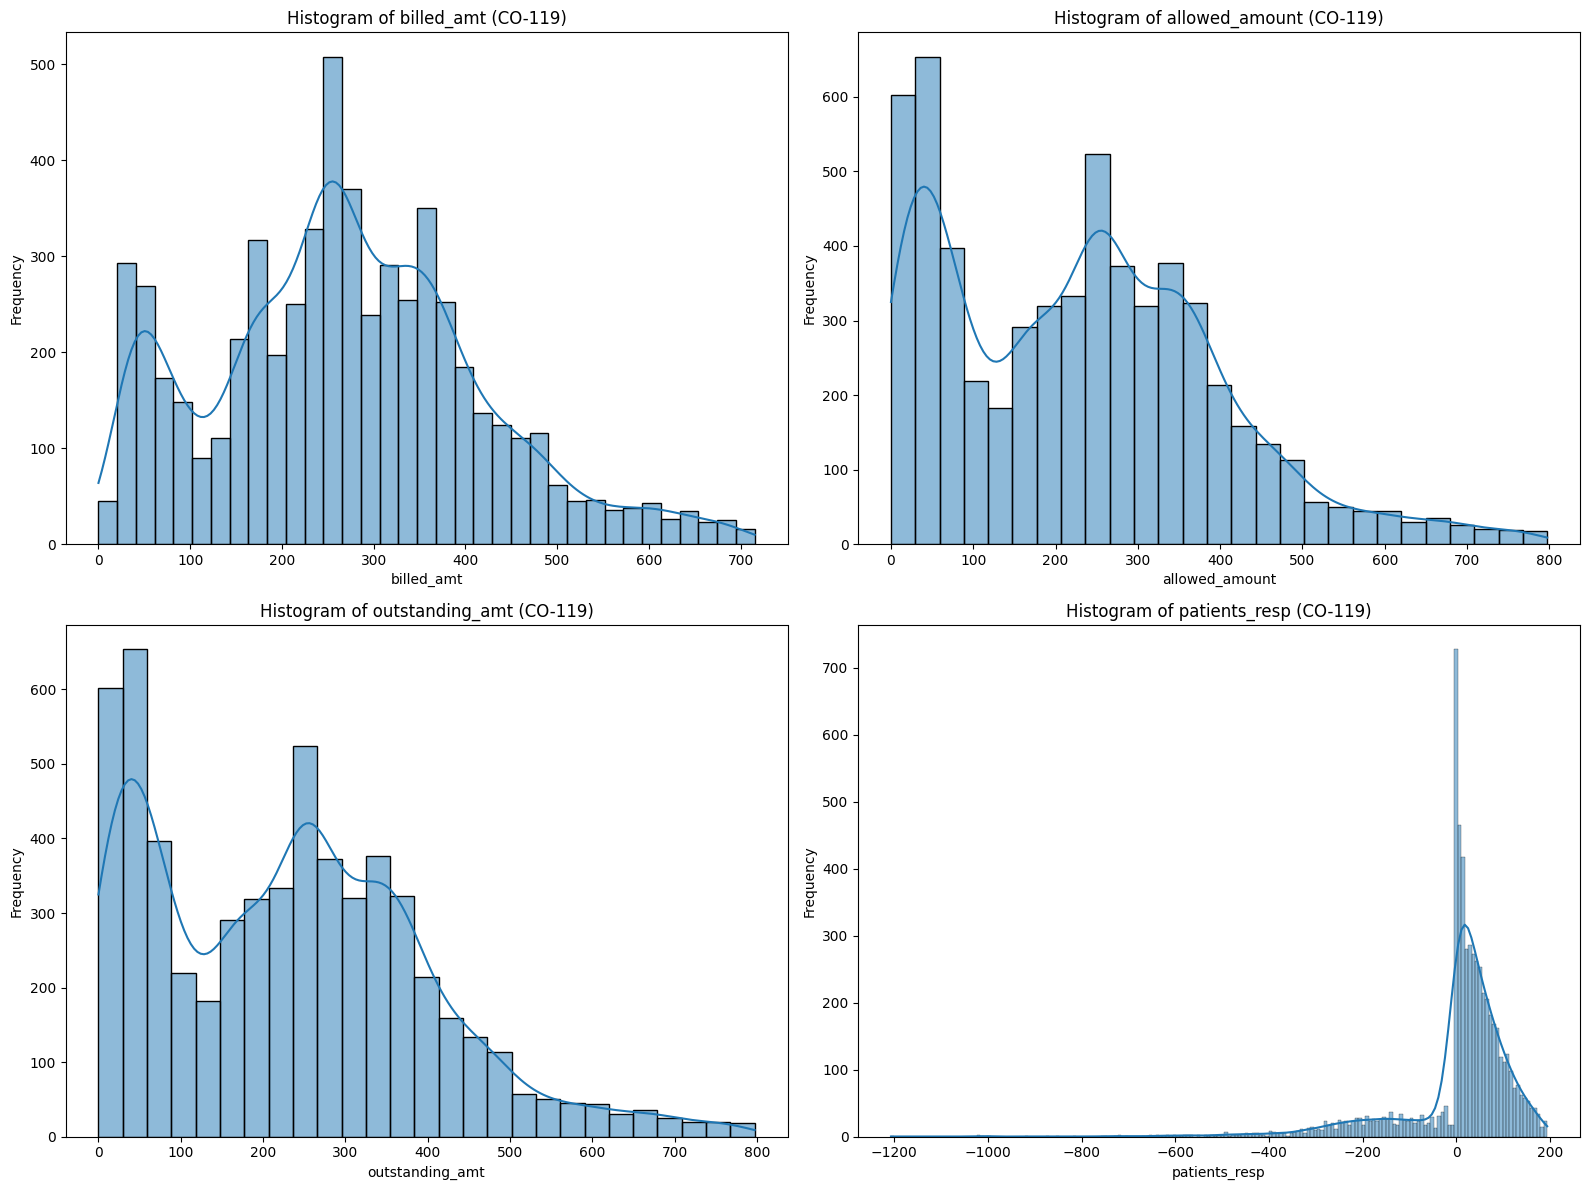

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only CO-119 cases
co119 = claim_data[claim_data["reason_code"].astype(str).str.contains("119", na=False)] # str.contains("119") finds rows related to CO-119

# Including only numerical columns
cols = ["billed_amt", "allowed_amount", "outstanding_amt", "patients_resp"]

# Creating the subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2x2 grid of subplots to plot all four variables together
axes = axes.flatten()  

#Loop through each numerical column and its corresponding subplot
for idx, col in enumerate(cols): 
    s = co119[col].dropna()

    # removing outliers
    q1 = s.quantile(0.25) #25th precentile
    q3 = s.quantile(0.75) #75th percentile
    iqr = q3 - q1
    #Defining the upper bound for outlier removal using the 1.5 * IQR rule
    upper_target = q3 + 1.5 * iqr

    # Filter within target
    filtered = s[s <= upper_target]

    # Plotting histogram
    sns.histplot(filtered, kde=True, ax=axes[idx]) # kde=True adds a smooth density curve on top of the histogram
    axes[idx].set_title(f"Histogram of {col} (CO-119)")
    axes[idx].set_xlabel(col) #labeling the x axis
    axes[idx].set_ylabel("Frequency") #labeling the y axis

plt.tight_layout()
plt.show()





Univariant Analysis of all Categorical Variables

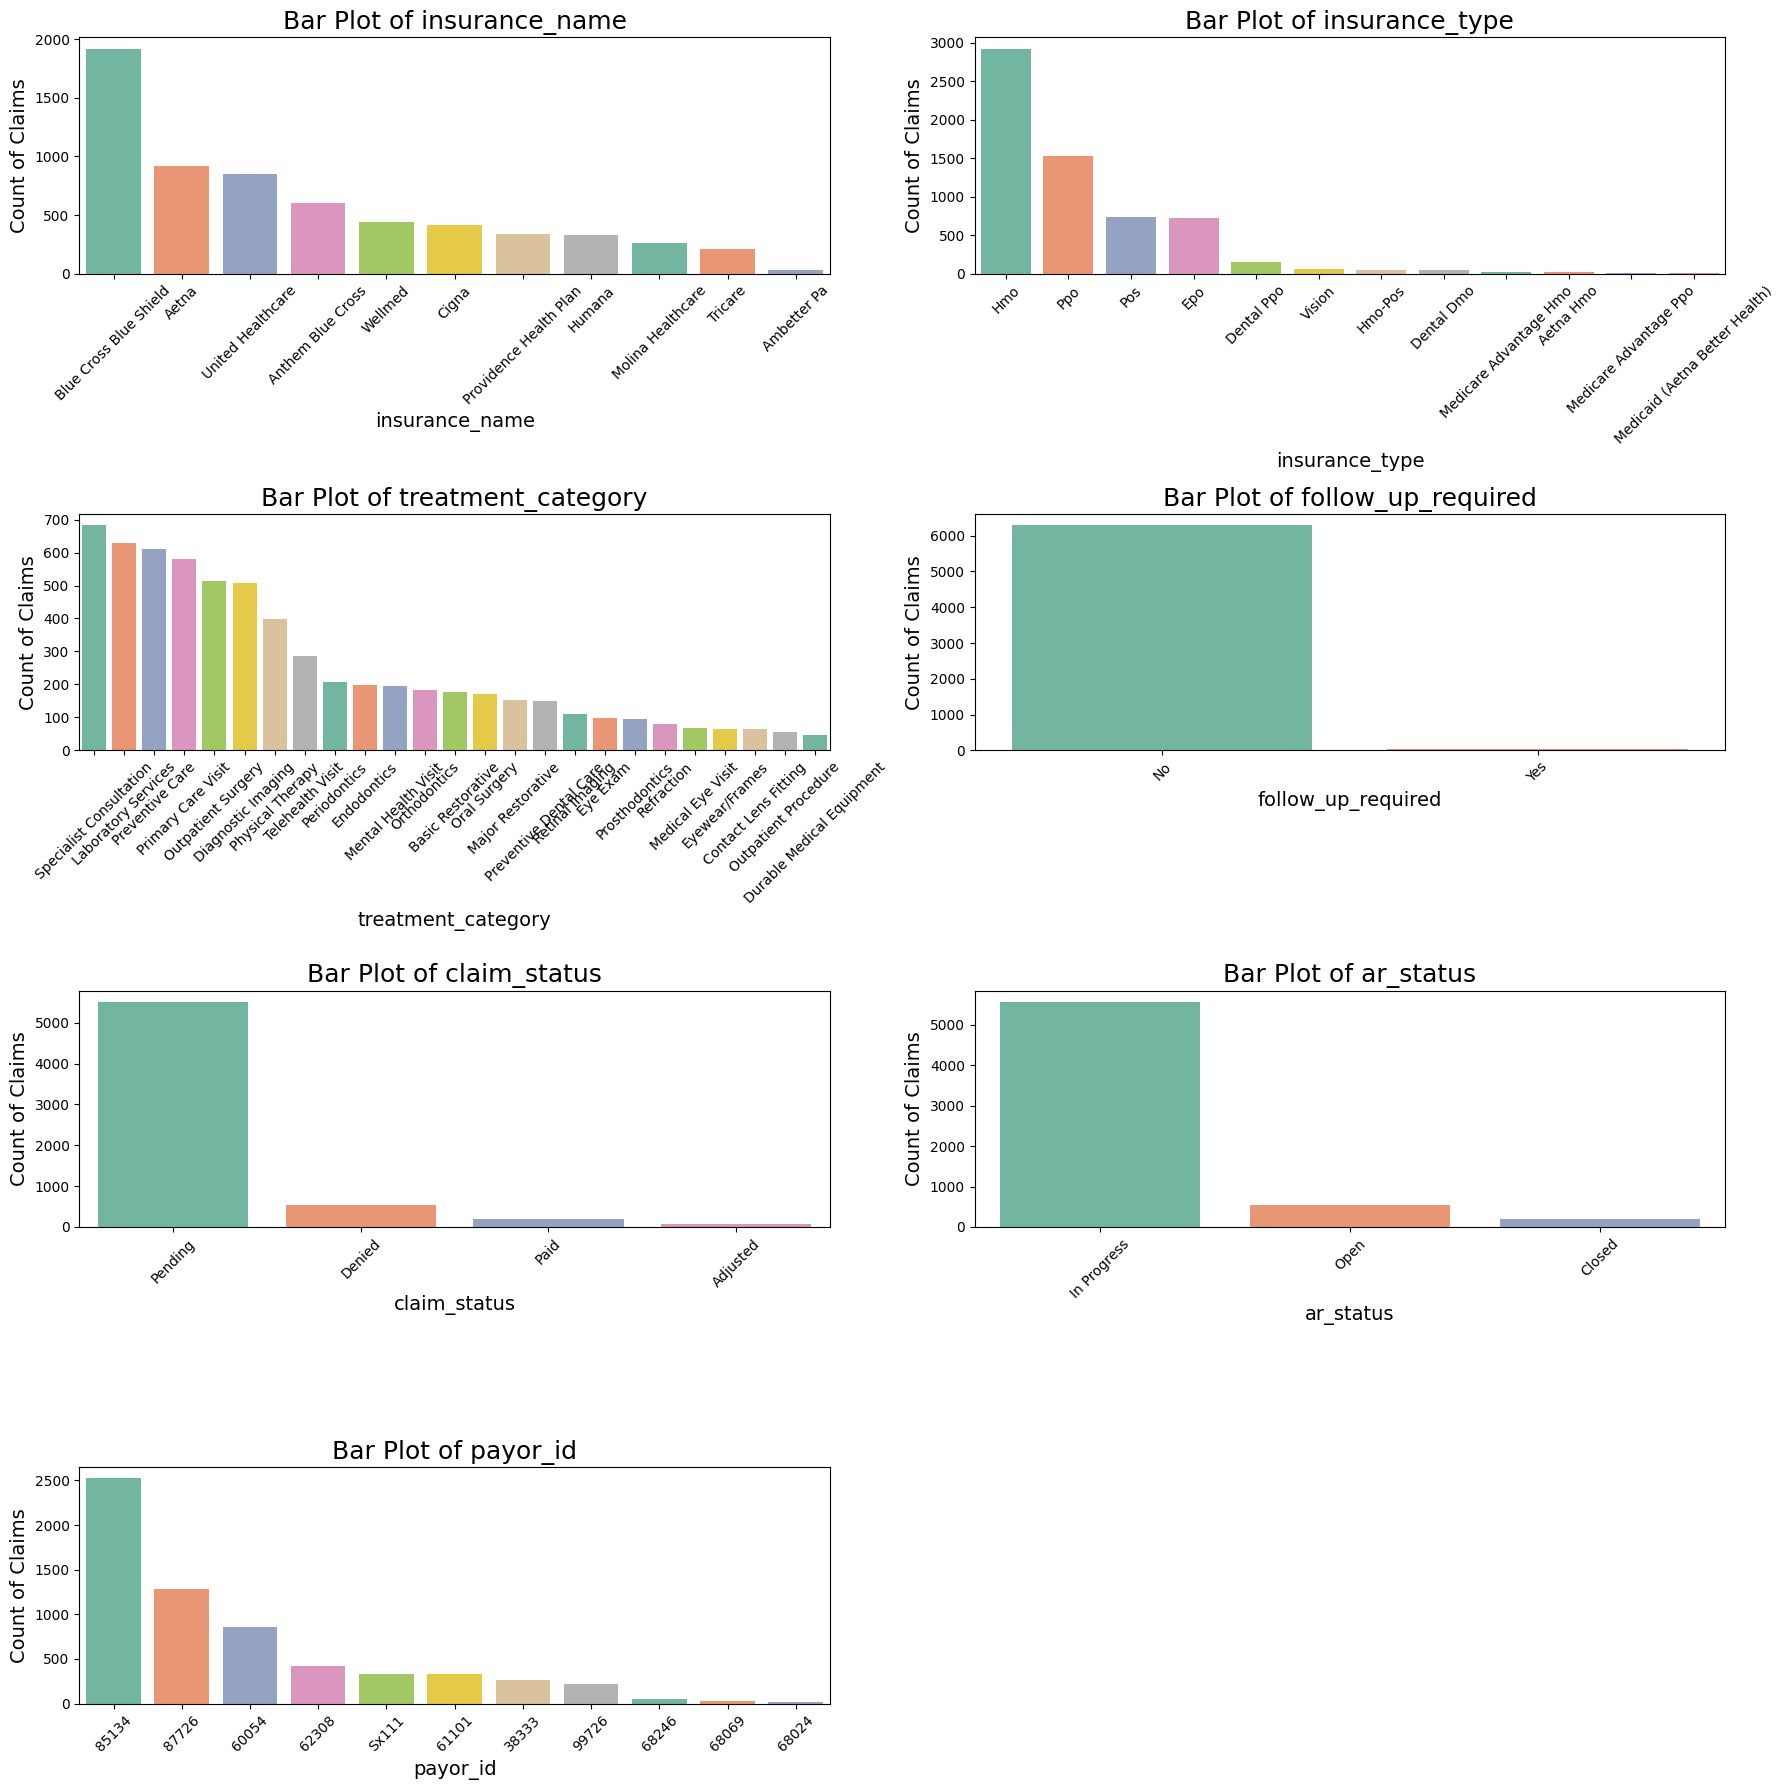

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

#Including only Categorical columns
cat_cols = ['insurance_name', 'insurance_type', 'treatment_category','follow_up_required','claim_status','ar_status',"payor_id"]

# Creating subplots 
fig, axes = plt.subplots(4, 2, figsize=(18, 18))
axes = axes.flatten()

#looping through all categorical columns and creating count plot
for idx, col in enumerate(cat_cols):
    sns.countplot(
        data=co119, 
        x=col, 
        order=co119[col].value_counts().index, #Ordering the bars by frequency (highest to lowest)
        palette="Set2",
        ax=axes[idx]
    )
    
    axes[idx].set_title(f"Bar Plot of {col}", fontsize=18)
    axes[idx].set_xlabel(col, fontsize=14)
    axes[idx].set_ylabel("Count of Claims", fontsize=14)
    axes[idx].tick_params(axis='x', rotation=45)
    
# Turning off the extra 8th subplot
for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")


plt.tight_layout()
plt.show()



Bivariant analysis of All Numerical Variables

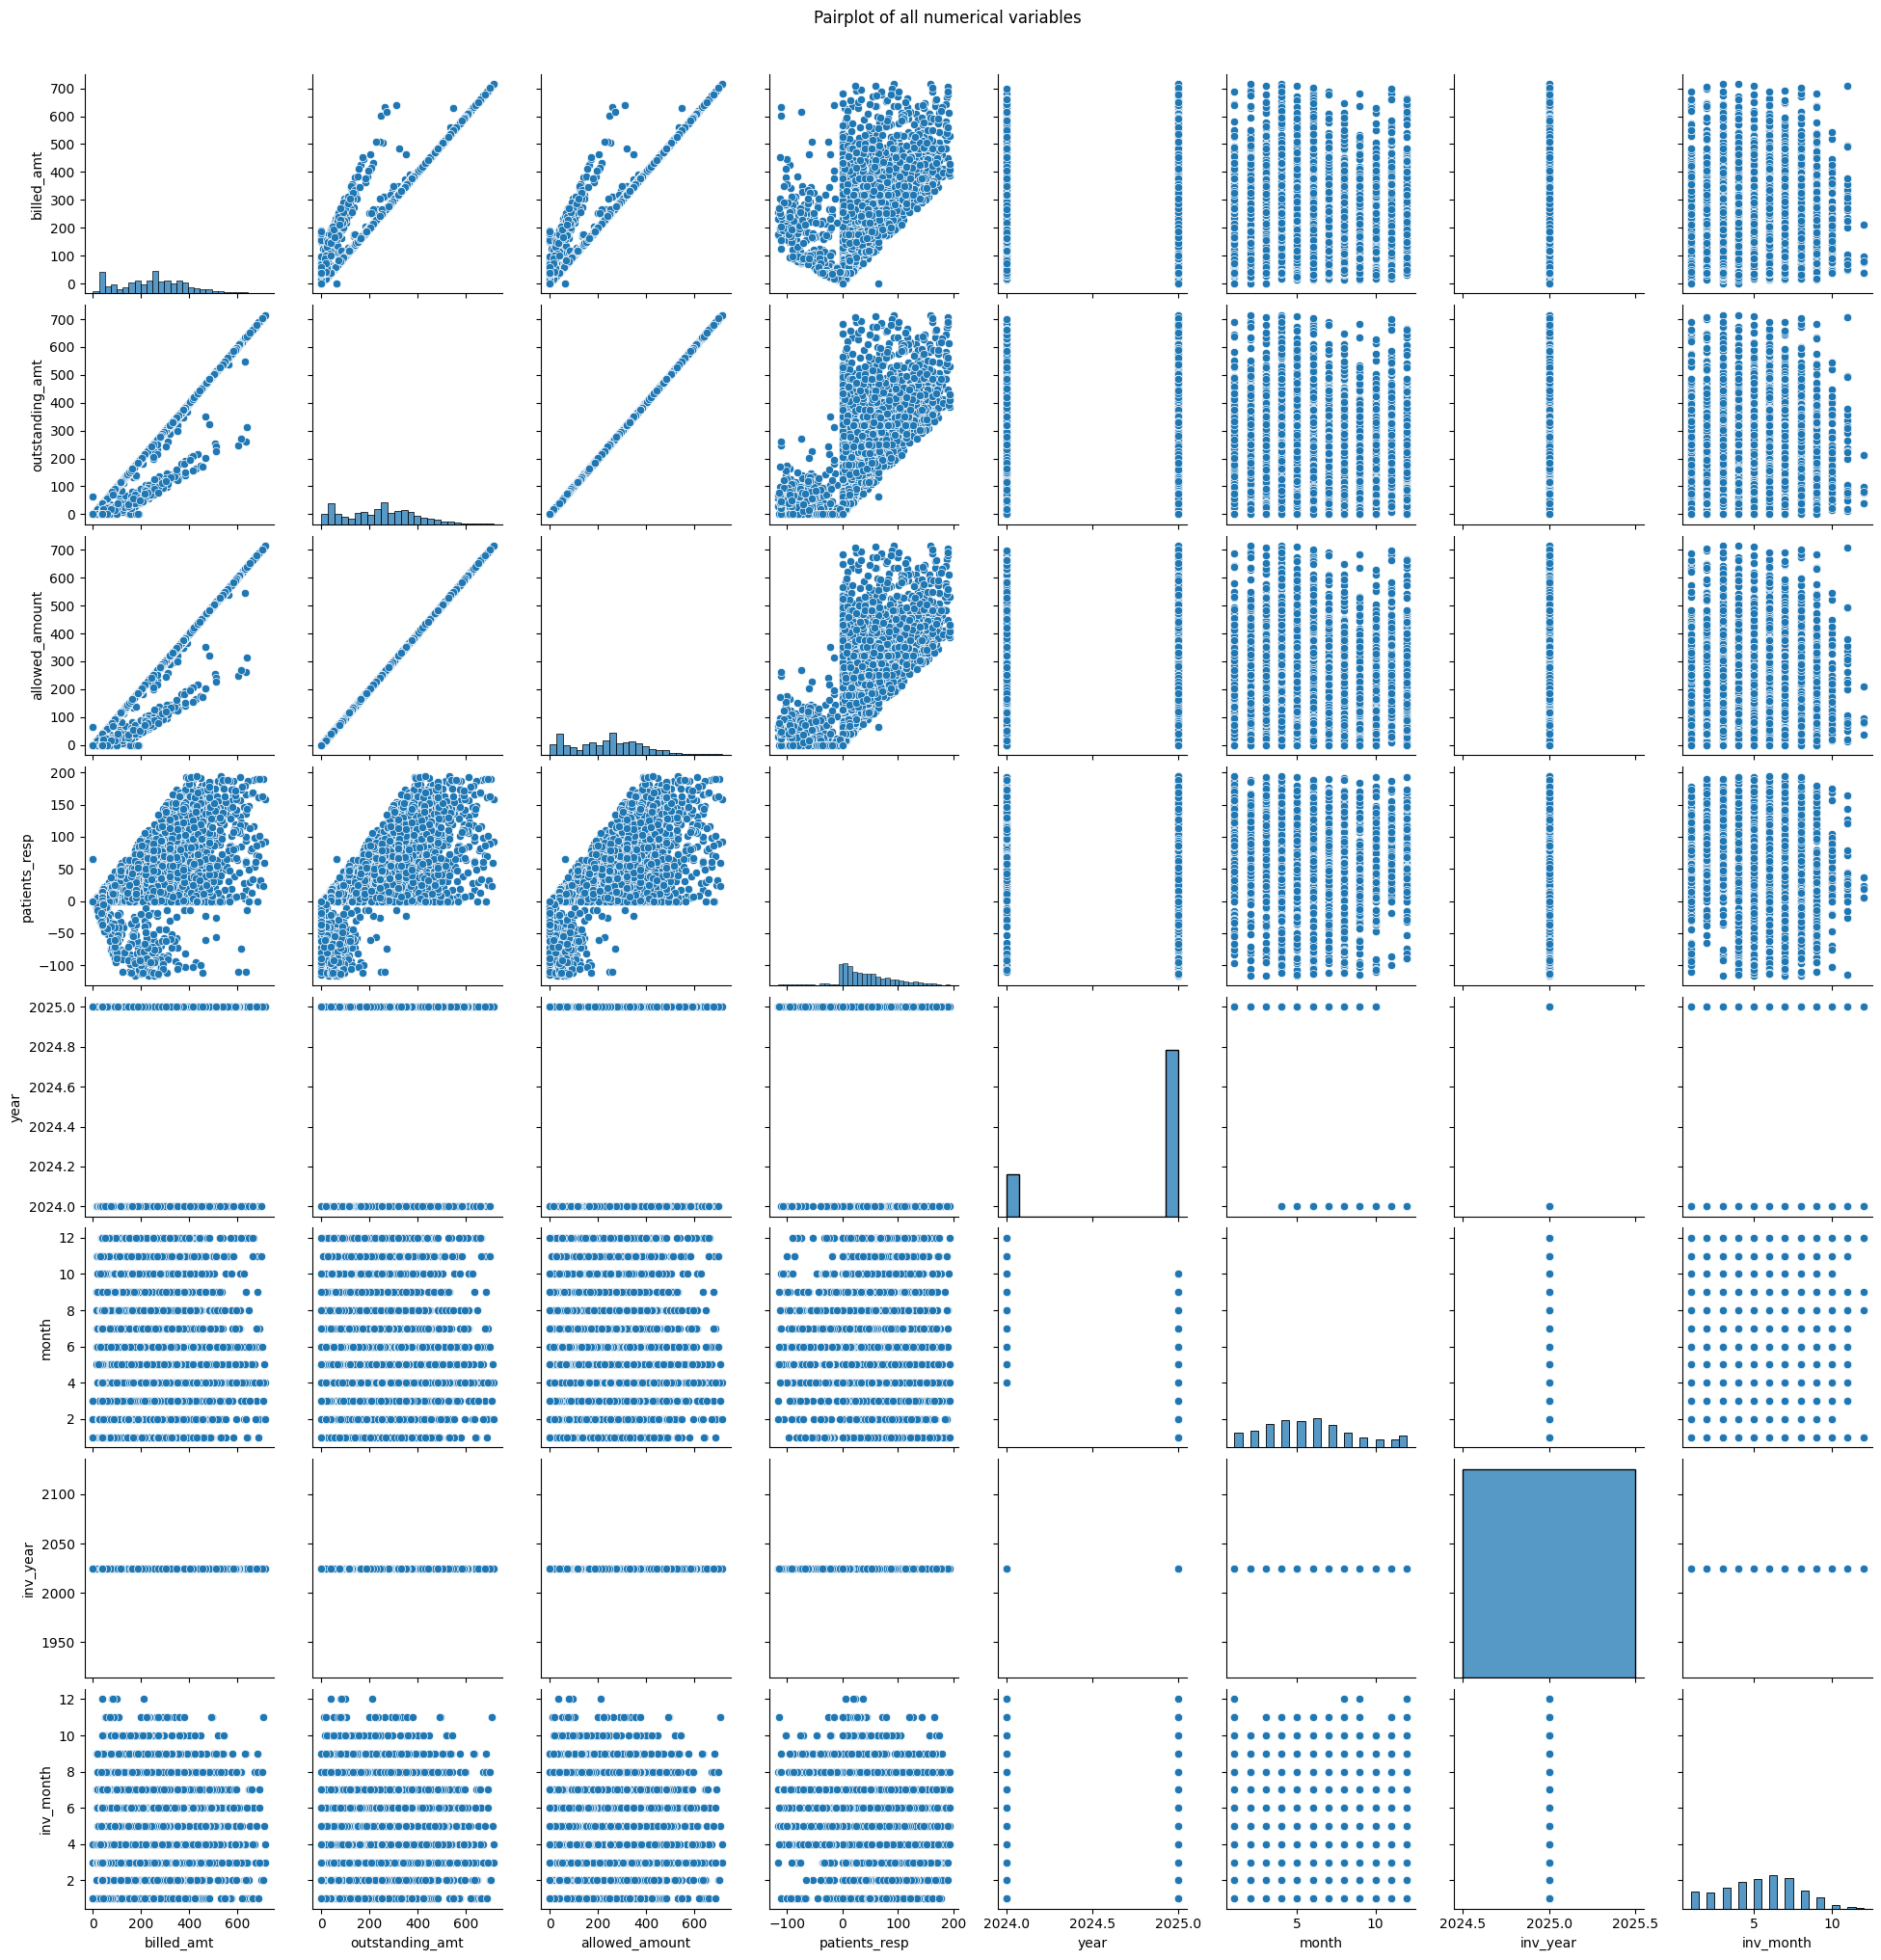

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Selecting only numerical columns
num_cols = co119.select_dtypes(include=['int64','float64']).columns.tolist()

# Removing the outliers
def remove_outliers_iqr(series):
    q1 = series.quantile(0.25) #25th percentile
    q3 = series.quantile(0.75) #75th percentile
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series >= lower) & (series <= upper)]

# Cleaning entire numeric dataset
clean_df = co119[num_cols].copy()

# Removing outliers from the current column using the IQR method
for col in num_cols:
    clean_df[col] = remove_outliers_iqr(clean_df[col])

clean_df = clean_df.dropna()

sns.pairplot(clean_df)
plt.suptitle("Pairplot of all numerical variables", y=1.02)
plt.show()


BiVariant Analysis of all Categorical Variables

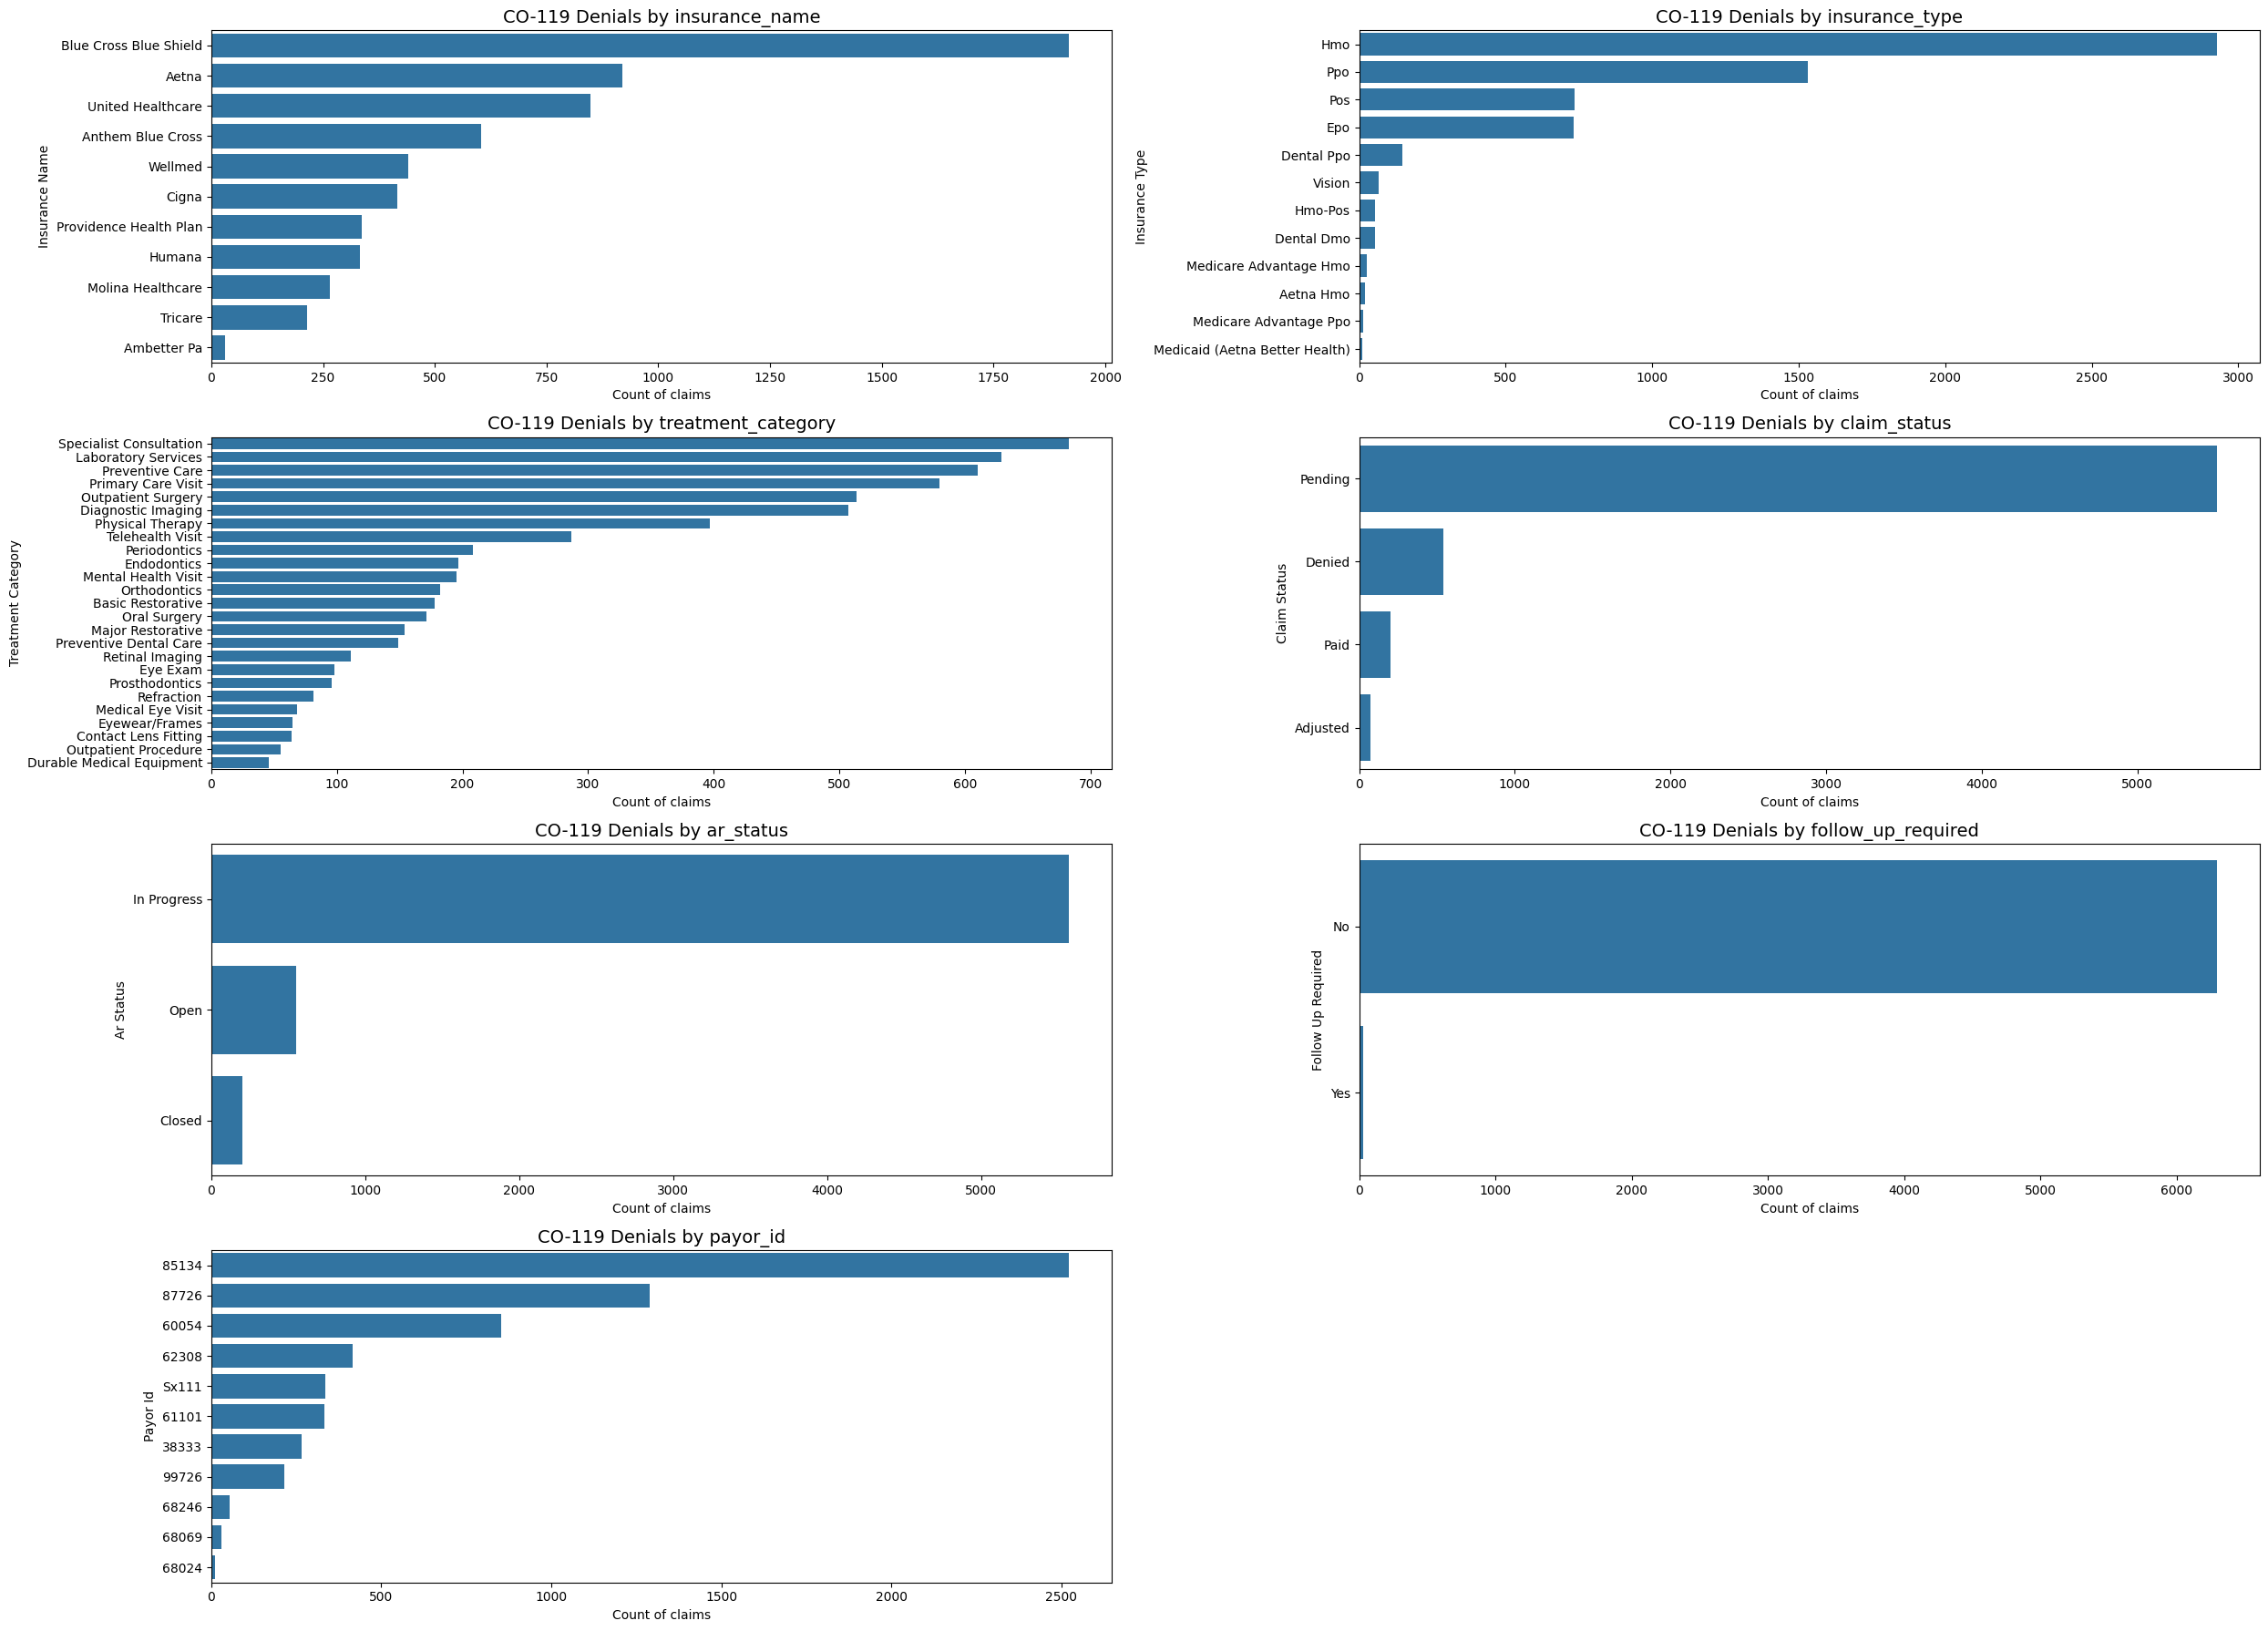

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_vars = ['insurance_name', 'insurance_type', 'treatment_category',
            'claim_status','ar_status',"follow_up_required","payor_id"]

plt.figure(figsize=(25, 18))

#loop through every categorical column
for i, col in enumerate(cat_vars):
    plt.subplot(4, 2, i+1)

    counts = co119[col].value_counts()

    sns.barplot(x=counts.values, y=counts.index)
    
    plt.title(f"CO-119 Denials by {col}", fontsize=14)
    plt.xlabel("Count of claims")
    plt.ylabel(col.replace("_", " ").title())

# Turning off the extra 8th subplot
for j in range(len(cat_vars), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Multi variant analysis of all numerical Variables

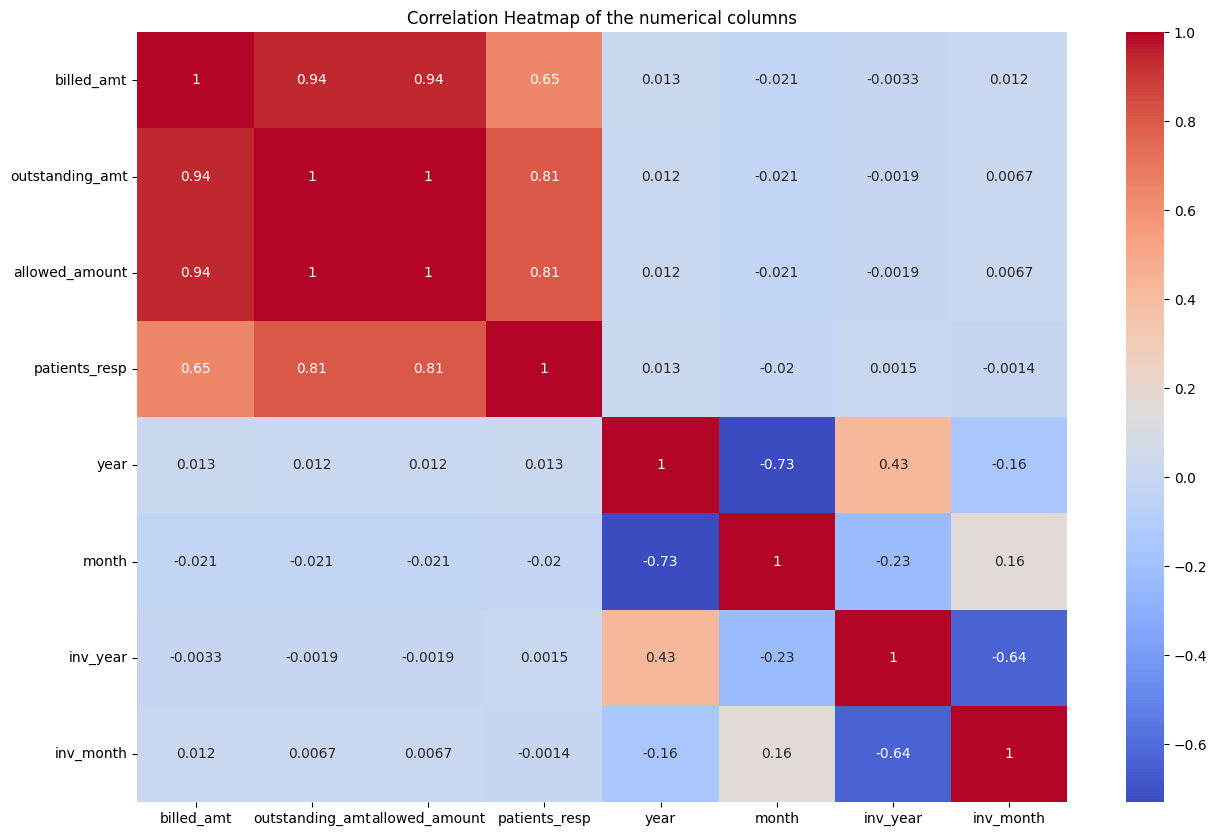

In [17]:
#correlation heatmap for all numerical features
corr_matrix = claim_data.select_dtypes(exclude=['object']).corr() #includes only numerical column
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of the numerical columns')
plt.show()

In [18]:
target = "claim_status"

cat_cols = [col for col in cat_cols if col != target]

print("Categorical variables are :", cat_cols)

Categorical variables are : ['insurance_name', 'insurance_type', 'treatment_category', 'follow_up_required', 'ar_status', 'payor_id']


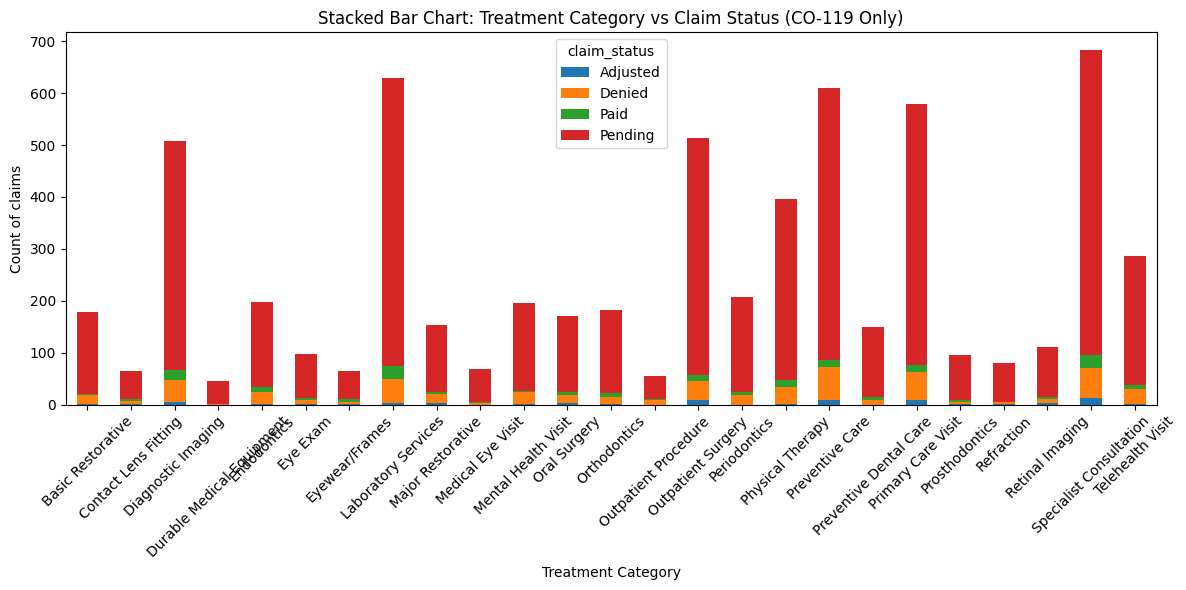

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Crosstab for CO119 denial between treatment category and claim_status
stacked = pd.crosstab(co119["treatment_category"], co119["claim_status"])

# Plotting stacked bar chart
stacked.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Stacked Bar Chart: Treatment Category vs Claim Status (CO-119 Only)")
plt.xlabel("Treatment Category")
plt.ylabel("Count of claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


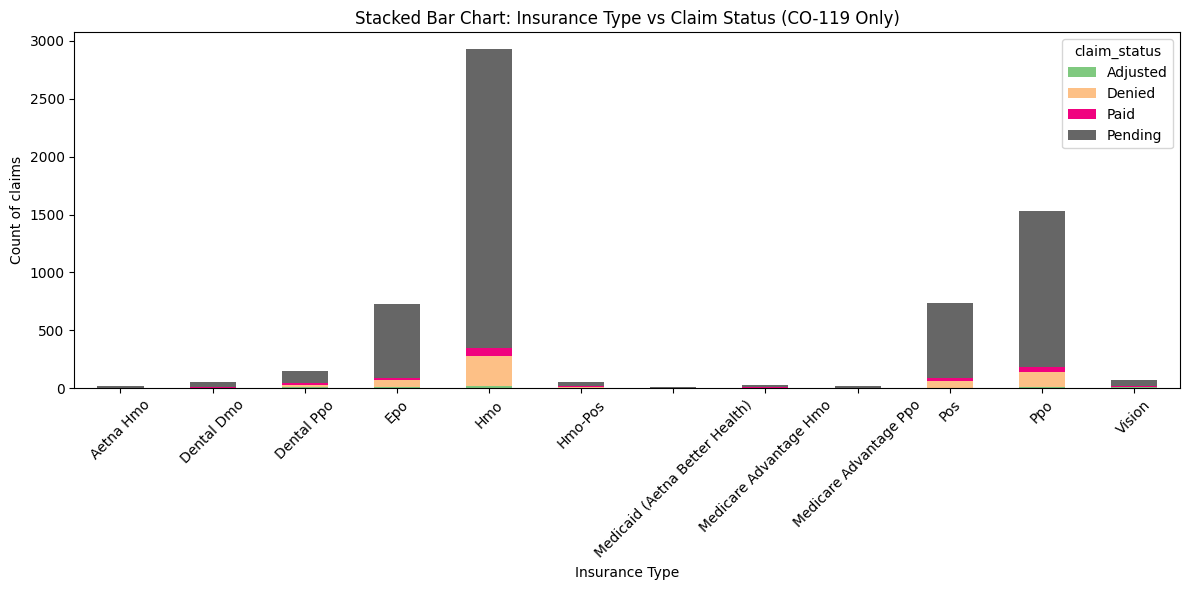

In [20]:
# Create crosstab for Insurance Type vs Claim Status (CO119 only)
stacked = pd.crosstab(co119["insurance_type"], co119["claim_status"])

# Plot stacked bar chart
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Insurance Type vs Claim Status (CO-119 Only)")
plt.xlabel("Insurance Type")
plt.ylabel("Count of claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


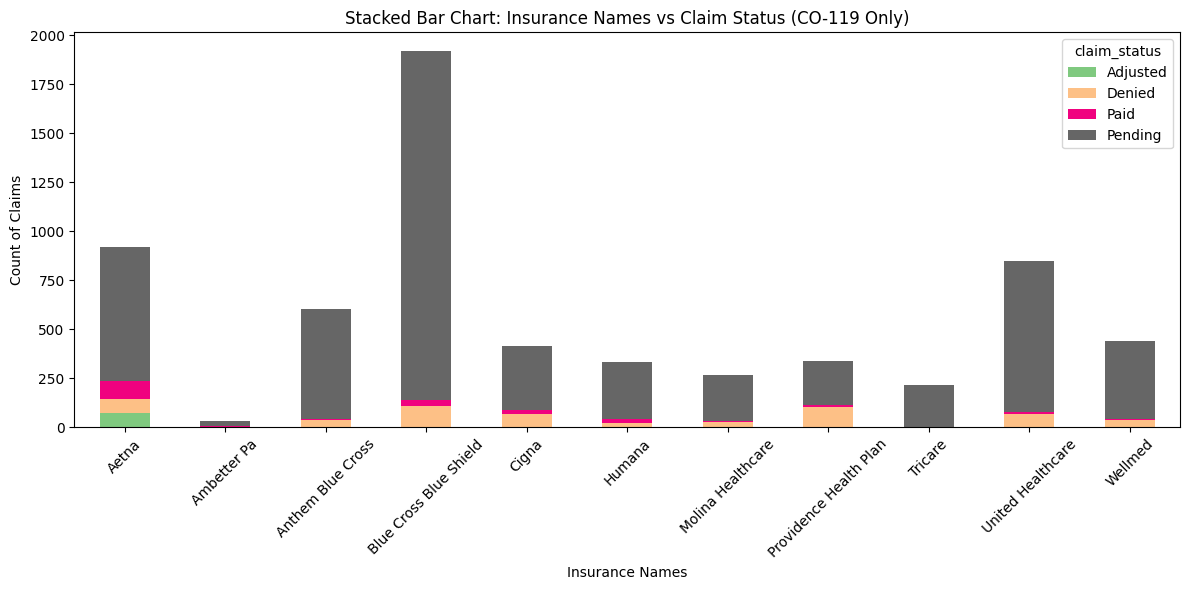

In [21]:
# Create crosstab for Insurance Names vs Claim Status (CO119 only)
stacked = pd.crosstab(co119["insurance_name"], co119["claim_status"])

# Plot stacked bar chart
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Insurance Names vs Claim Status (CO-119 Only)")
plt.xlabel("Insurance Names")
plt.ylabel("Count of Claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

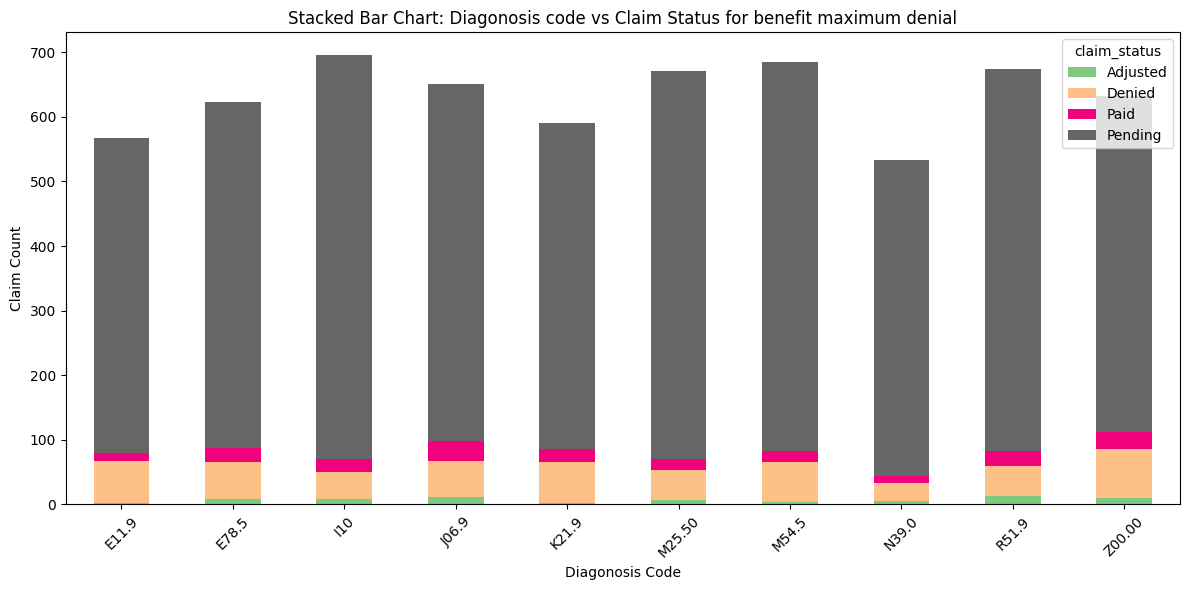

In [22]:
stacked = pd.crosstab(co119["diagnosis_code"], co119["claim_status"])

# Plotting stacked bar chart
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Diagonosis code vs Claim Status for benefit maximum denial")
plt.xlabel("Diagonosis Code")
plt.ylabel("Claim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

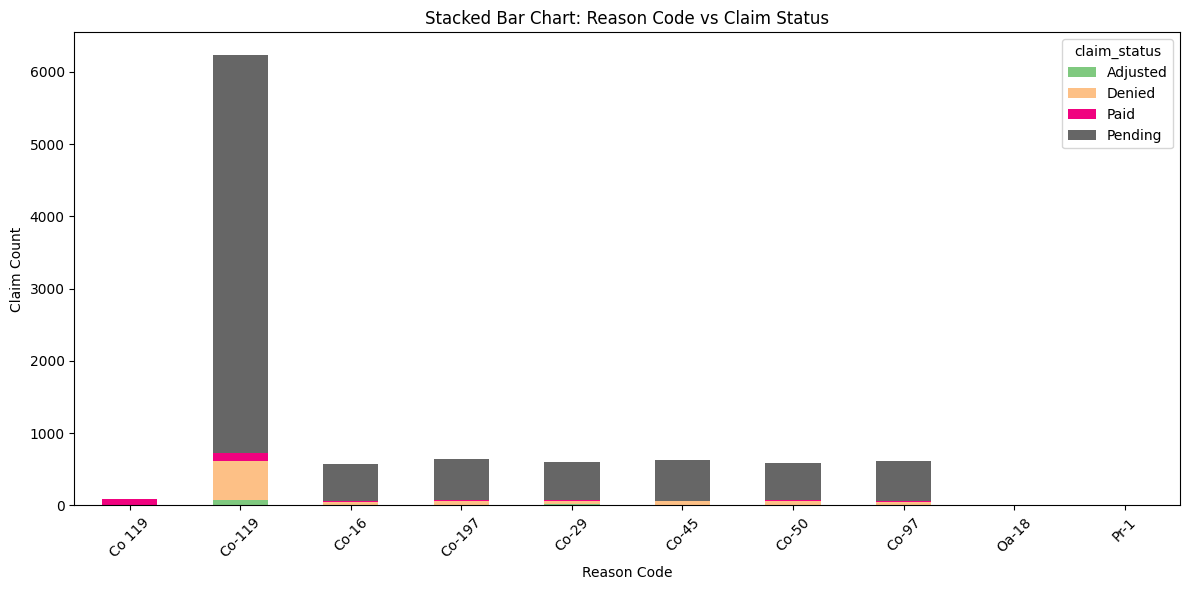

In [23]:
stacked = pd.crosstab(claim_data["reason_code"], claim_data["claim_status"])
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Reason Code vs Claim Status")
plt.xlabel("Reason Code")
plt.ylabel("Claim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

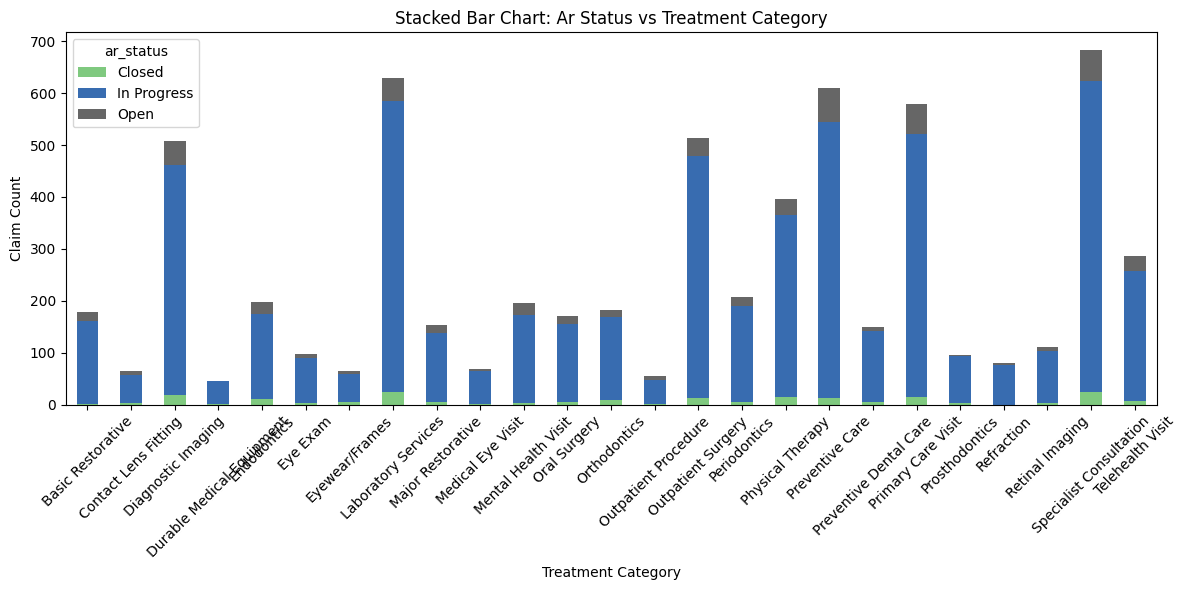

In [24]:
stacked = pd.crosstab(co119["treatment_category"], co119["ar_status"])
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Ar Status vs Treatment Category")
plt.xlabel("Treatment Category")
plt.ylabel("Claim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

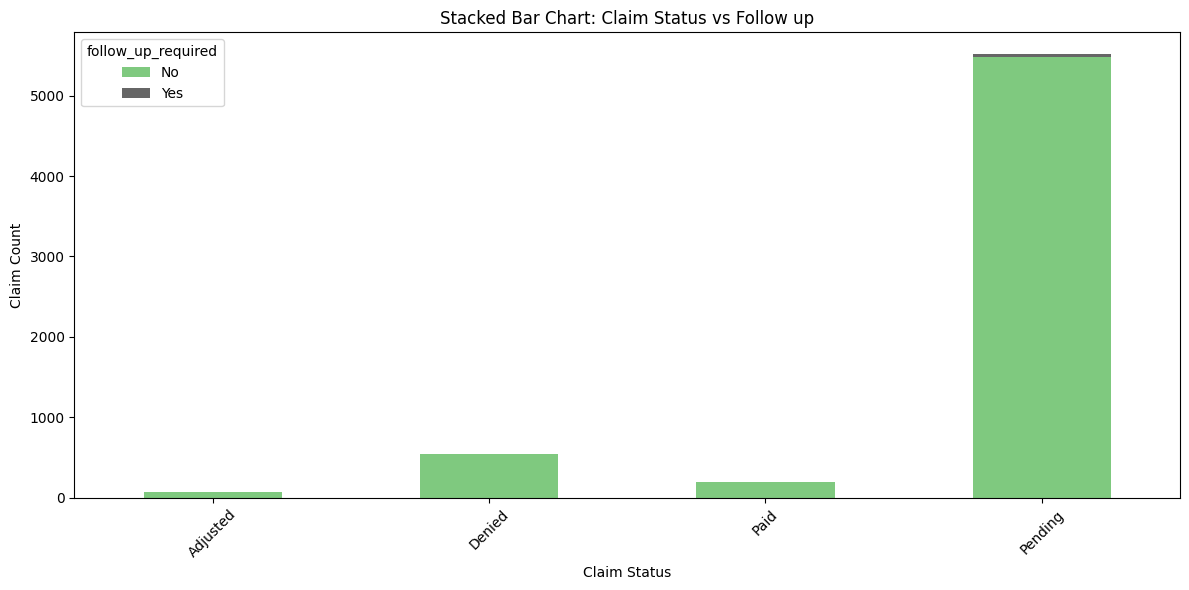

In [25]:
stacked = pd.crosstab(co119["claim_status"], co119["follow_up_required"])

stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Claim Status vs Follow up")
plt.xlabel("Claim Status")
plt.ylabel("Claim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

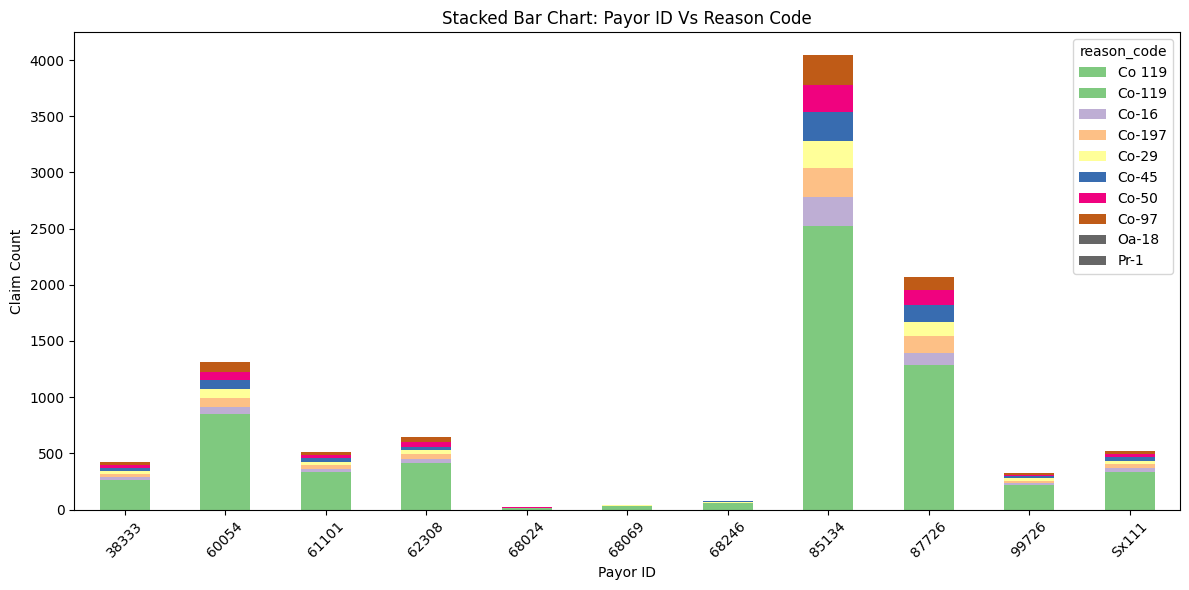

In [26]:
stacked = pd.crosstab(claim_data["payor_id"], claim_data["reason_code"])
stacked.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Accent")

plt.title("Stacked Bar Chart: Payor ID Vs Reason Code")
plt.xlabel("Payor ID")
plt.ylabel("Claim Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()